In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib
import matplotlib.pyplot as plt
import random
import seaborn as sns
import pandas as pd
import scipy.stats as stats

import os
import numpy as np
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
from quad_model import *
from tensorflow.keras.models import Model, load_model
from  tqdm import tqdm

import mukund_utils as utils

random.seed(100)
np.random.seed(100)

model_keras = load_model('custom_adjacency_regularizer_20210731_124_step3.h5')
pre_tuner_model = Model(inputs=model_keras.inputs, outputs=model_keras.get_layer("energy_seq_struct").output)

def sigmoid(z):
    return 1.0/(1.0 + np.exp(-z))

def sigmoid_tuner(activation):
    return (sigmoid(np.array(model_keras.get_layer("gen_func")(np.array([[activation] ]))).flatten()))

baeza_et_al_data = pd.read_excel("baeza_et_al_untreated_only.xls")

baeza_et_al_data["es7_flanked_seq"] = baeza_et_al_data.apply(
    lambda x: utils.add_flanking("CAAA"+x.Sequence+"AAC", 10), axis=1)

In [2]:
from joblib import load, dump

In [3]:
baeza_et_al_data["pre_tuner_predictions"] = pre_tuner_model(utils.create_input_data(list(baeza_et_al_data.es7_flanked_seq), )[:-1]).numpy().flatten()

scaling=0.3333333333333333


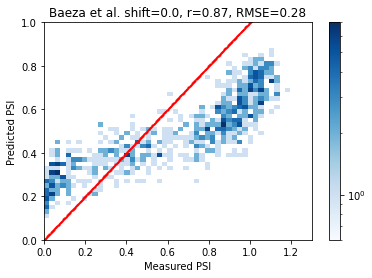

scaling=0.5


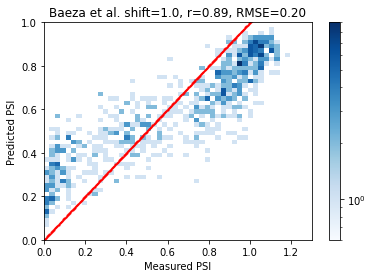

scaling=0.75


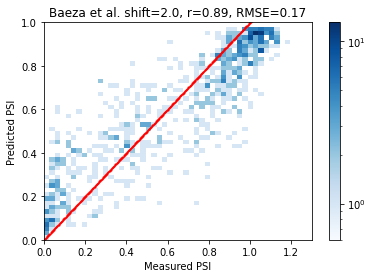

scaling=1


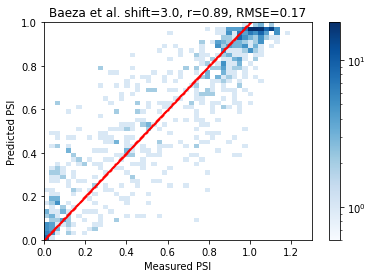

scaling=1.3333333333333333


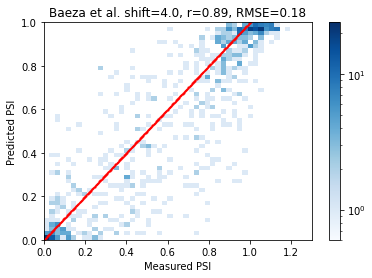

scaling=1.5


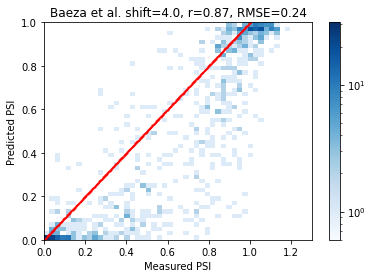

scaling=2


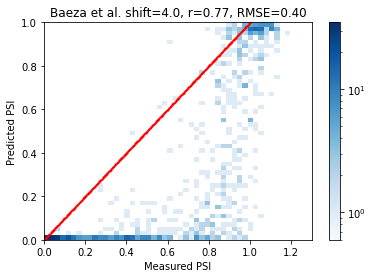

In [4]:
filtered_data = baeza_et_al_data[baeza_et_al_data["PSI.Standard.Deviation"] < 0.1]

min_rmse = np.inf
best_scaling = None
xy_data = None

for scaling in (1/3,1/2,3/4,1,4/3,3/2,2):
    # find the best shift so the wild type PSI matches the predicted PSI
    all_shifts = np.arange(-5,5,1)
    best_shift_index = np.argmin(np.linalg.norm(np.array(filtered_data["Mean.PSI"]).reshape(-1,1) - np.vectorize(sigmoid_tuner)((np.array(filtered_data.pre_tuner_predictions*scaling).reshape(-1,1) + all_shifts.reshape(1,-1)))
                                , axis=0))
    shift = all_shifts[best_shift_index]

    num_bins = 50
    x = filtered_data["Mean.PSI"]
    y = np.vectorize(sigmoid_tuner)(filtered_data.pre_tuner_predictions*scaling+shift)
    plt.hist2d(x,y,range=[[0,1.3],[0,1]], bins=[num_bins,num_bins], cmap='Blues', norm=matplotlib.colors.LogNorm(vmin=0.6))
    plt.xlabel("Measured PSI")
    plt.ylabel("Predicted PSI")
    plt.colorbar()

    reg = stats.linregress(x , y)
    rmse = np.sqrt(((x-y)**2).mean())
    
    # save best rmse model
    if rmse < min_rmse:
        best_scaling = scaling
        min_rmse = rmse
        xy_data = (x, y)

    left,right = plt.xlim()
    grid = np.linspace(left,right,500)
    #plt.scatter(grid, reg.intercept + grid * reg.slope, s=1, c='r')
    plt.scatter(grid, grid, s=1, c='r')

    print(f"scaling={scaling}")
    #plt.title(f"Baeza et al. scaling = {scaling:.2f}, slope = {reg.slope:.2f}, r = {reg.rvalue:.2f}") # intercept = {reg.intercept:.2f}, 
    #plt.title(f"Baeza et al. scaling = {scaling:.2f}, slope = {reg.slope:.2f}, r = {reg.rvalue:.2f}") 
    plt.title(f"Baeza et al. shift={shift:.1f}, r={reg.rvalue:.2f}, RMSE={rmse:.2f}") # intercept = {reg.intercept:.2f}, 

    plt.show()

In [5]:
bx, by = xy_data

In [6]:
dump([(bx, by)], 'baeza_et_al.pkl')

['baeza_et_al.pkl']

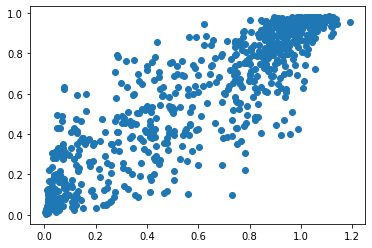

In [7]:
plt.scatter(bx, by)